In [11]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
cols = ['ts', 'next_ts', 'ttl', 'create_ts', 'freq', 'last_ts', 'update_ts', 'revals', 'good_rv', 'bad_rv', 'mime', 'size']
dfs = [pd.read_csv(f'../traces/expiry/r6fb_{c}.csv.zst', names=cols) for c in ['a', 'b', 'c']]
df = pd.concat(dfs)
df = df[df['ttl'] != 0]
df

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime,size
0,77,77,4294967295,77,1,77,77,0,0,0,2,292
1,116,0,30,85,1,85,85,0,0,0,7,354
2,116,0,30,85,1,85,85,0,0,0,6,619
3,116,122,1,114,1,114,114,0,0,0,28,1138
4,117,0,30,86,1,86,86,0,0,0,6,618
...,...,...,...,...,...,...,...,...,...,...,...,...
4145707,691324,0,900,690423,1,690423,690423,484551,365414,119137,28,201
4145708,691325,0,30,691294,1,691294,691294,484551,365414,119137,24,4
4145709,691325,0,30,691294,1,691294,691294,484551,365414,119137,6,354
4145710,691325,0,4294967295,691325,1,691325,691325,484551,365414,119137,9,338


In [13]:
pd.read_csv('../traces/expiry/r6fb_b.csv.zst', names=cols, nrows=5)

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime,size
0,29,29,4294967295,29,1,29,29,0,0,0,15,0
1,30,85,4294967295,30,1,30,30,0,0,0,15,0
2,45,45,4294967295,45,1,45,45,0,0,0,7,383
3,45,45,4294967295,45,1,45,45,0,0,0,7,383
4,45,45,4294967295,45,1,45,45,0,0,0,7,383


# feature engineering

In [14]:
def calc_features(df):
    df['should_reval'] = (df['ts'] <= df['next_ts']) & (df['next_ts'] <= (df['ts'] + df['ttl'])) & (df['ttl'] < 7 * 86400)
    df['generations'] = ((df['ts'] - df['create_ts'] - 1) / df['ttl']).round()
    df['t_since_last'] = df['ts'] - df['last_ts']
    df['t_since_last_frac'] = (df['t_since_last'] - 1)/ df['ttl']
    return df

display(calc_features(df).sort_values(by='ts').head(10))
df['should_reval'].value_counts(normalize=True)

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime,size,should_reval,generations,t_since_last,t_since_last_frac
0,29,29,4294967295,29,1,29,29,0,0,0,15,0,False,-0.0,0,-2.328306e-10
1,30,85,4294967295,30,1,30,30,0,0,0,15,0,False,-0.0,0,-2.328306e-10
3,45,45,4294967295,45,1,45,45,0,0,0,7,383,False,-0.0,0,-2.328306e-10
2,45,45,4294967295,45,1,45,45,0,0,0,7,383,False,-0.0,0,-2.328306e-10
4,45,45,4294967295,45,1,45,45,0,0,0,7,383,False,-0.0,0,-2.328306e-10
5,48,176747,4294967295,48,1,48,48,0,0,0,16,0,False,-0.0,0,-2.328306e-10
14,51,51,4294967295,51,1,51,51,0,0,0,7,2581629,False,-0.0,0,-2.328306e-10
15,51,51,4294967295,51,1,51,51,0,0,0,7,2581629,False,-0.0,0,-2.328306e-10
11,51,51,4294967295,51,1,51,51,0,0,0,7,2581629,False,-0.0,0,-2.328306e-10
21,51,51,4294967295,51,1,51,51,0,0,0,7,2581629,False,-0.0,0,-2.328306e-10


should_reval
False    0.827203
True     0.172797
Name: proportion, dtype: float64

# training

In [15]:
from sklearn.model_selection import train_test_split
import skl2onnx
from skl2onnx.common.data_types import FloatTensorType
import pickle
from imblearn.over_sampling import RandomOverSampler

def split_xy(df):
    y = df['should_reval']
    x = df[['ttl', 'freq', 'generations', 't_since_last', 't_since_last_frac', 'mime', 'size']]
    return x, y

x, y = split_xy(df)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)
xt_over, yt_over = RandomOverSampler(random_state=42).fit_resample(x_train, y_train) # type: ignore

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rfc = RandomForestClassifier(n_estimators=32, criterion = 'gini', min_samples_leaf = 0.01, random_state=42, n_jobs=-1)
rfc.fit(xt_over, yt_over)
y_pred = rfc.predict(x_test)
print(f'Train acc: {accuracy_score(yt_over, rfc.predict(xt_over)):0.4f}')
print(f'Test acc: {accuracy_score(y_test, y_pred):0.4f}')

gini = pd.Series(rfc.feature_importances_, index=xt_over.columns).sort_values(ascending=False)
display(gini)
print(classification_report(y_test, y_pred))

Train acc: 0.8899
Test acc: 0.9194


ttl                  0.337655
size                 0.214974
t_since_last         0.209018
t_since_last_frac    0.127454
mime                 0.043959
generations          0.035605
freq                 0.031335
dtype: float64

              precision    recall  f1-score   support

       False       0.97      0.93      0.95   5275300
        True       0.73      0.84      0.78   1101959

    accuracy                           0.92   6377259
   macro avg       0.85      0.89      0.87   6377259
weighted avg       0.93      0.92      0.92   6377259



ROC AUC: 0.9503
Average Precision (AP): 0.8571


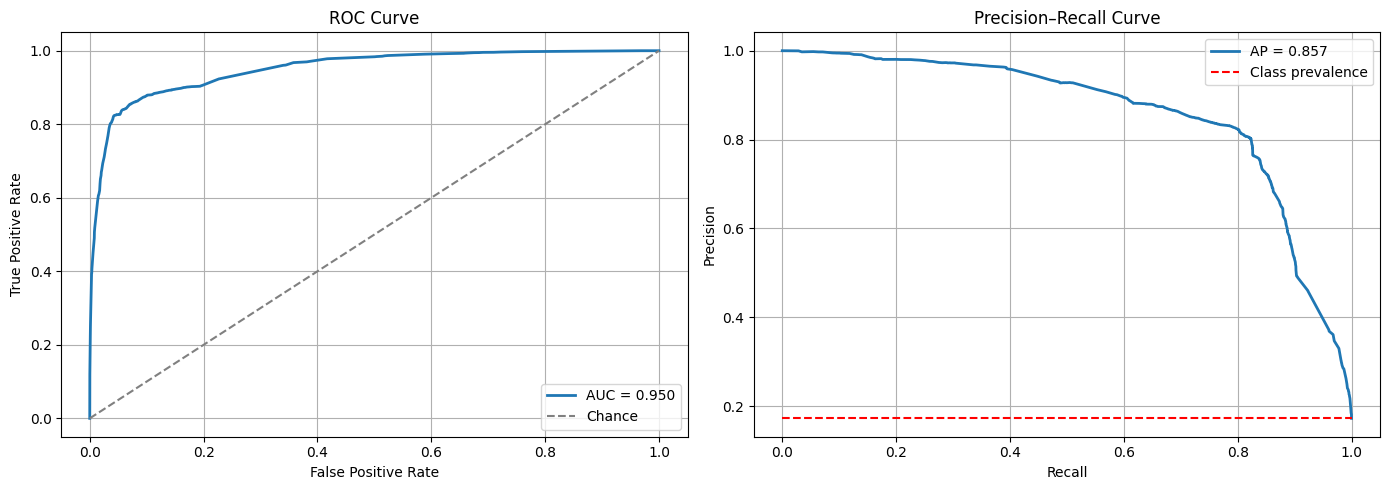

In [17]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_scores = rfc.predict_proba(x_test)[:, 1]
fpr, tpr, roc_thresholds = roc_curve(y_test, y_scores)
auc_value = roc_auc_score(y_test, y_scores)
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_scores)
ap_value = average_precision_score(y_test, y_scores)

plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_value:.3f}")
plt.plot([0,1], [0,1], '--', color='gray', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(recall, precision, linewidth=2, label=f"AP = {ap_value:.3f}")
plt.hlines(y_test.mean(), 0, 1, colors='red', linestyles='--', label="Class prevalence")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

print(f"ROC AUC: {auc_value:.4f}")
print(f"Average Precision (AP): {ap_value:.4f}")

In [18]:
name = 'rfc_fb_all_v6'
m = rfc

with open(f'../models/{name}.pkl', 'wb') as f:
    pickle.dump(m, f)

onnx = skl2onnx.to_onnx(
    m,
    initial_types=[('in', FloatTensorType([None, x_train.shape[1]]))],  # type: ignore
    options={'zipmap': False},
    verbose=1)
with open(f'../models/{name}.onnx', 'wb') as f:
    f.write(onnx.SerializeToString())  # type: ignore

# file size of the onnx model
import os
print(f'ONNX model size: {os.path.getsize(f"../models/{name}.onnx") / 1024:.2f} KB')

[to_onnx] initial_types=[('in', FloatTensorType(shape=[None, 7]))]
[convert_sklearn] parse_sklearn_model


[convert_sklearn] convert_topology
[convert_operators] begin
[convert_operators] iteration 1 - n_vars=0 n_ops=1
[call_converter] call converter for 'SklearnRandomForestClassifier'.
[convert_operators] end iter: 1 - n_vars=3
[convert_operators] iteration 2 - n_vars=3 n_ops=1
[convert_operators] end iter: 2 - n_vars=3
[convert_operators] end.
[_update_domain_version] +opset 0: name='ai.onnx.ml', version=1
[convert_topology] +opset: name='', version=21
[convert_sklearn] end
ONNX model size: 63.26 KB


In [19]:
# from sklearn.neural_network import MLPClassifier

# mlp = MLPClassifier(hidden_layer_sizes=(16, 32, 32, 16), max_iter=200, early_stopping=True, random_state=42)
# mlp.fit(x_train, y_train)

# y_pred = mlp.predict(x_test)
# print(f'Train acc: {accuracy_score(y_train, mlp.predict(x_train)):0.4f}')
# print(f'Test acc: {accuracy_score(y_test, y_pred):0.4f}')
# print(classification_report(y_test, y_pred))

# transferability

In [20]:
for subdf in dfs:
    subdf = calc_features(subdf)
    x, y = split_xy(subdf)
    y_pred = rfc.predict(x)
    acc = accuracy_score(y, y_pred)
    print(f'CF acc: {acc:0.4f}')
    print(classification_report(y, y_pred))


CF acc: 0.9186
              precision    recall  f1-score   support

       False       0.96      0.94      0.95   4087900
        True       0.72      0.79      0.76    774066

    accuracy                           0.92   4861966
   macro avg       0.84      0.87      0.85   4861966
weighted avg       0.92      0.92      0.92   4861966

CF acc: 0.9246
              precision    recall  f1-score   support

       False       0.97      0.94      0.95   8504256
        True       0.75      0.86      0.80   1813093

    accuracy                           0.92  10317349
   macro avg       0.86      0.90      0.88  10317349
weighted avg       0.93      0.92      0.93  10317349

CF acc: 0.9069
              precision    recall  f1-score   support

       False       0.97      0.91      0.94   3393558
        True       0.69      0.87      0.77    752154

    accuracy                           0.91   4145712
   macro avg       0.83      0.89      0.86   4145712
weighted avg       0.92      

In [21]:
dfcftest = pd.read_csv(f'../traces/expiry/cf_a.csv.zst', names=cols, nrows=1000)
dfcftest = calc_features(dfcftest)
dfcftest.head()

FileNotFoundError: [Errno 2] No such file or directory: '../traces/expiry/cf_a.csv.zst'

In [ ]:
for c in ['a', 'c', 'e', 'g']:
    dfs = pd.read_csv(f'../traces/expiry/cf_{c}.csv.zst', names=cols, skiprows = lambda i : i > 0 and random.random() > 0.005)
    dfs = calc_features(dfs)
    dfs = dfs[dfs['ttl'] != 0]
    x, y = split_xy(dfs)
    y_pred = rfc.predict(x)
    acc = accuracy_score(y, y_pred)
    print(f'CF {c} acc: {acc:0.4f}')
    print(classification_report(y, y_pred))

CF a acc: 0.9839
              precision    recall  f1-score   support

       False       0.99      1.00      0.99    120608
        True       0.47      0.18      0.26      1917

    accuracy                           0.98    122525
   macro avg       0.73      0.59      0.63    122525
weighted avg       0.98      0.98      0.98    122525

CF b acc: 0.9871
              precision    recall  f1-score   support

       False       0.99      1.00      0.99    356504
        True       0.40      0.16      0.23      4332

    accuracy                           0.99    360836
   macro avg       0.70      0.58      0.61    360836
weighted avg       0.98      0.99      0.98    360836

CF c acc: 0.9924
              precision    recall  f1-score   support

       False       0.99      1.00      1.00    296126
        True       0.49      0.30      0.38      2238

    accuracy                           0.99    298364
   macro avg       0.74      0.65      0.69    298364
weighted avg       0.99

In [ ]:
dfwm = pd.read_csv(f'../traces/expiry/wm_t.csv.zst', names=cols, skiprows = lambda i : i > 0 and random.random() > 0.002)
dfwm = calc_features(dfwm)
dfwm = dfwm[dfwm['ttl'] != 0]
x, y = split_xy(dfwm)
y_pred = rfc.predict(x)
acc = accuracy_score(y, y_pred)
print(f'CF {c} acc: {acc:0.4f}')
print(classification_report(y, y_pred))

CF c acc: 0.7943
              precision    recall  f1-score   support

       False       0.78      0.91      0.84     56979
        True       0.83      0.62      0.71     38811

    accuracy                           0.79     95790
   macro avg       0.80      0.77      0.78     95790
weighted avg       0.80      0.79      0.79     95790

